In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("Placement_Data_Full_Class.csv")

In [2]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.\n")
print(df.info())

Dataset has 215 rows and 15 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB
None


In [3]:
print(df.isnull().sum())

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64


How salary packages are spread out.

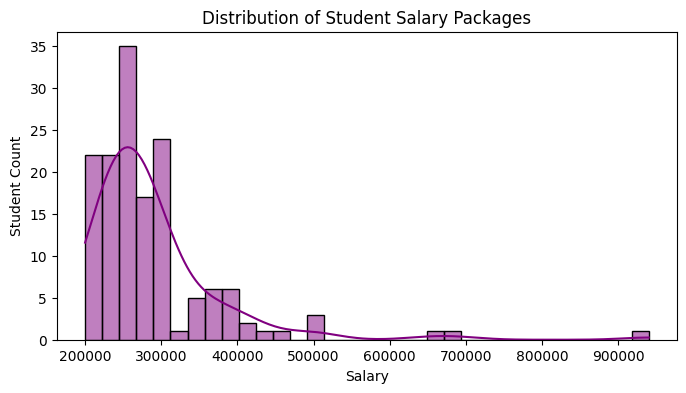

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df['salary'].dropna(), kde=True, color='purple')
plt.title("Distribution of Student Salary Packages")
plt.xlabel("Salary")
plt.ylabel("Student Count")
plt.show()

Does previous professional experience significantly change whether a student gets placed?
Percentage distribution of placement status by work experience

In [6]:
experience_vs_placement = pd.crosstab(df['workex'], df['status'], normalize='index') * 100
print(experience_vs_placement.round(2))

status  Not Placed  Placed
workex                    
No           40.43   59.57
Yes          13.51   86.49


In [7]:
raw_counts = pd.crosstab(df['workex'], df['status'])
percentages = pd.crosstab(df['workex'], df['status'], normalize='index') * 100

print("--- Raw Student Counts ---")
print(raw_counts)
print("\n--- Percentage Breakdown by Row (%) ---")
print(percentages.round(2))

--- Raw Student Counts ---
status  Not Placed  Placed
workex                    
No              57      84
Yes             10      64

--- Percentage Breakdown by Row (%) ---
status  Not Placed  Placed
workex                    
No           40.43   59.57
Yes          13.51   86.49


Map out which numerical grades (High School %, Undergrad %, or Aptitude Test Scores) share the strongest statistical connection with getting a job.

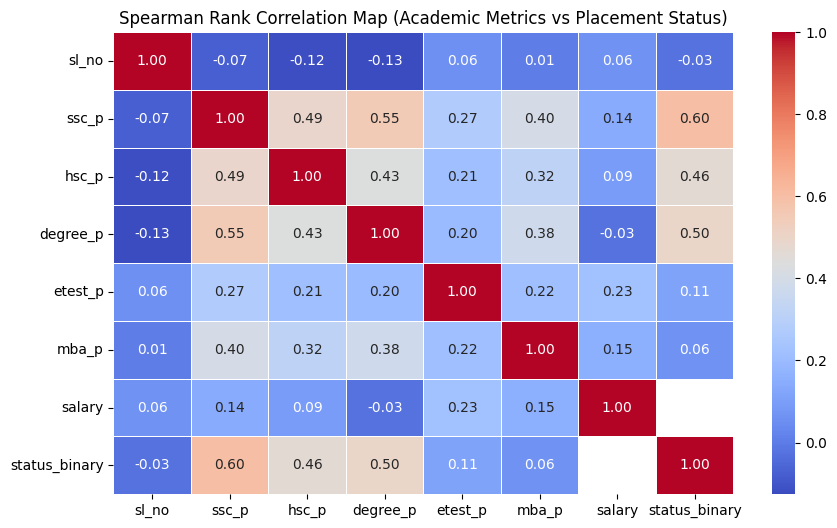

In [8]:
explore_df = df.copy()
explore_df['status_binary'] = explore_df['status'].map({'Placed': 1, 'Not Placed': 0})

# Select only the relevant numerical features for our matrix
numerical_cols = explore_df.select_dtypes(include=[np.number]).columns
# Calculate the Spearman rank correlation matrix
correlation_matrix = explore_df[numerical_cols].corr(method='spearman')
# Render a heatmap visual to locate the strongest drivers
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Spearman Rank Correlation Map (Academic Metrics vs Placement Status)")
plt.show()